In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip -q install transformers accelerate bitsandbytes sentencepiece langdetect --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 22.9 MB/s eta 0:00:00


In [3]:
import os, glob, warnings, re, json as pyjson
warnings.filterwarnings('ignore')

# ---- EDIT THIS if different: same BASE_DIR used in Notebooks 1 & 2 ----
BASE_DIR = '/content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset'
# ---------------------------------------------------------------------

def find_file(base_dir, filename):
    matches = glob.glob(os.path.join(base_dir, '**', filename), recursive=True)
    return matches[0] if matches else None

OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')
FIG_DIR    = os.path.join(BASE_DIR, 'figures')

evidence_path = find_file(OUTPUT_DIR, 'forecast_evidence_for_llm.csv')
print('FOUND' if evidence_path else 'MISSING', 'forecast_evidence_for_llm.csv', evidence_path or '')
assert evidence_path, 'Could not find Notebook 2 output. Run Notebook 2 first.'


FOUND forecast_evidence_for_llm.csv /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/forecast_evidence_for_llm.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

evidence_df = pd.read_csv(evidence_path, parse_dates=['target_week', 'forecast_origin_week'])
print(evidence_df.shape)
evidence_df.head()


(64, 12)


,target_week,horizon_weeks,forecast_origin_week,point_forecast,lower_80,upper_80,actual_cases,high_risk_probability,high_risk_threshold,top_feature_1,top_feature_2,top_feature_3
0,2025-09-15,1,2025-09-08,4631.9,3407.8,4323.4,3375.0,0.33,4252.0,cases_lag1,week_cos,week_sin
1,2025-09-22,1,2025-09-15,4819.7,3625.9,5405.9,685.0,0.67,4252.0,cases_lag1,week_cos,week_sin
2,2025-09-29,1,2025-09-22,4546.9,3625.4,4267.7,3196.0,0.67,4252.0,cases_lag1,week_cos,week_sin
3,2025-10-06,1,2025-09-29,5551.7,4341.4,4659.6,4115.0,0.67,4252.0,cases_lag1,week_cos,week_sin
4,2025-10-13,1,2025-10-06,2480.2,2131.5,2643.7,3656.0,0.00,4252.0,cases_lag1,week_cos,week_sin


## 1. Models to compare

Three models, matching your proposal's "Qwen / Llama" reasoning-layer choice plus a size ablation:

| Model | Why it's included |
|---|---|
| `Qwen/Qwen2.5-7B-Instruct` | Primary Qwen candidate |
| `NousResearch/Meta-Llama-3.1-8B-Instruct` | Llama candidate. This is an **ungated mirror** of Meta's official weights, used so you don't need to request Meta's license approval just to run this notebook. Functionally identical weights. |
| `Qwen/Qwen2.5-3B-Instruct` | Smaller-model ablation - does hallucination/faithfulness get worse with a cheaper model? Relevant to a low-resource-deployment framing. |

Loaded **one at a time** (not all three simultaneously) so this fits on a free-tier Colab GPU (T4, ~16GB) — each model is loaded, used for generation, then unloaded before the next one loads.

In [5]:
import torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('GPU memory (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

MODELS_TO_COMPARE = [
    'Qwen/Qwen2.5-7B-Instruct',
    'NousResearch/Meta-Llama-3.1-8B-Instruct',
    'Qwen/Qwen2.5-3B-Instruct',
]

def load_model(model_name):
    print(f'Loading {model_name} ...')
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map='auto')
    print(f'Loaded {model_name}.')
    return tok, mdl

def unload_model(tok, mdl):
    del tok, mdl
    gc.collect()
    torch.cuda.empty_cache()


CUDA available: True
GPU: Tesla T4
GPU memory (GB): 15.6


## 2. Feature name -> plain-language descriptions

Used both to build the prompt (so the LLM sees human-readable factor names, not raw column names) and to check afterward whether the LLM's explanation actually references the factors it was given.

In [6]:
FEATURE_INFO = {
    'cases_lag1':  ('dengue cases reported in the most recent week', ['recent case', 'last week', 'past week', 'current case']),
    'cases_lag2':  ('dengue cases from 2 weeks ago', ['2 week', 'two week', 'recent case']),
    'cases_lag4':  ('dengue cases from 4 weeks ago', ['4 week', 'four week', 'recent case', 'past month']),
    'cases_lag8':  ('dengue cases from 8 weeks ago', ['8 week', 'eight week', 'past case']),
    'cases_lag12': ('dengue cases from 12 weeks ago', ['12 week', 'twelve week']),
    'rain_roll4':  ('recent 4-week average rainfall', ['rain', 'rainfall', 'precipitation', 'monsoon']),
    'temp_roll4':  ('recent 4-week average temperature', ['temperature', 'warm', 'heat']),
    'humidity_roll4': ('recent 4-week average humidity', ['humidity', 'humid']),
    'week_sin': ('seasonal time-of-year pattern', ['season', 'time of year', 'monsoon', 'seasonal']),
    'week_cos': ('seasonal time-of-year pattern', ['season', 'time of year', 'monsoon', 'seasonal']),
    'is_eid_window': ('proximity to an Eid holiday (mass travel period)', ['eid', 'holiday', 'travel', 'migration']),
    'days_to_nearest_eid': ('proximity to an Eid holiday (mass travel period)', ['eid', 'holiday', 'travel']),
    'is_outbreak_year_2023': ('the 2023 outbreak-year effect', ['2023', 'outbreak year', 'record year']),
    'avg_temp': ('average temperature', ['temperature', 'warm', 'heat']),
    'avg_humidity': ('average humidity', ['humidity', 'humid']),
    'total_rain': ('total rainfall', ['rain', 'rainfall', 'precipitation']),
    'avg_wind': ('average wind speed', ['wind']),
}

def feature_label(col):
    return FEATURE_INFO.get(col, (col, [col]))[0]

def feature_synonyms(col):
    return FEATURE_INFO.get(col, (col, [col]))[1]


## 3. Build the evidence-grounded prompt

The system prompt explicitly forbids inventing numbers not present in the evidence block — this is the intervention we evaluate for effectiveness in the hallucination check below.

In [7]:
SYSTEM_PROMPT = (
    "You are a public-health risk communication assistant supporting dengue outbreak surveillance in Bangladesh. "
    "You will be given a structured forecast evidence block in JSON. Write a risk explanation for a public-health officer. "
    "STRICT RULES: "
    "(1) Only use the numbers given to you in the evidence block. Do not invent, estimate, or round in a way that introduces "
    "a new case count, percentage, or date not present in the evidence. "
    "(2) Explicitly name which of the given contributing factors are driving this forecast. Do not invent factors not listed. "
    "(3) State a risk level (Low / Moderate / High) consistent with the given high_risk_probability. "
    "(4) Keep the explanation to 3-5 sentences. Reflect the width of the prediction interval in how confident you sound. "
    "(5) After the English explanation, add a line 'BANGLA:' followed by a Bangla-language translation of the same explanation."
)

def build_prompt(row):
    evidence = {
        'forecast_target_week': str(row['target_week'].date()),
        'horizon_weeks_ahead': int(row['horizon_weeks']),
        'point_forecast_cases': row['point_forecast'],
        'lower_80pct_interval': row['lower_80'],
        'upper_80pct_interval': row['upper_80'],
        'high_risk_probability_pct': round(row['high_risk_probability'] * 100, 0),
        'high_risk_threshold_cases': row['high_risk_threshold'],
        'top_contributing_factors': [
            feature_label(row['top_feature_1']),
            feature_label(row['top_feature_2']),
            feature_label(row['top_feature_3']),
        ],
    }
    user_msg = 'Evidence:\n' + pyjson.dumps(evidence, indent=2) + '\n\nWrite the risk explanation now.'
    return evidence, user_msg

def generate_explanation(row, tok, mdl, max_new_tokens=280):
    evidence, user_msg = build_prompt(row)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_msg},
    ]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(prompt, return_tensors='pt').to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    text = tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return evidence, text.strip()


In [8]:
N_PER_HORIZON = 3
sample_rows = (
    evidence_df.dropna(subset=['actual_cases'])
    .groupby('horizon_weeks', group_keys=False)
    .apply(lambda g: g.sample(min(N_PER_HORIZON, len(g)), random_state=42))
    .reset_index(drop=True)
)
print('Will generate explanations for', len(sample_rows), 'forecast rows, x', len(MODELS_TO_COMPARE), 'models =',
      len(sample_rows) * len(MODELS_TO_COMPARE), 'total generations.')

generations = []
for model_name in MODELS_TO_COMPARE:
    tok, mdl = load_model(model_name)
    for i, row in sample_rows.iterrows():
        evidence, text = generate_explanation(row, tok, mdl)
        generations.append({'model': model_name, 'row_index': i, 'horizon_weeks': row['horizon_weeks'],
                             'target_week': row['target_week'], 'evidence': evidence, 'raw_output': text})
        print(f"  [{model_name}] [{i+1}/{len(sample_rows)}] horizon={row['horizon_weeks']}w done")
    unload_model(tok, mdl)
    print(f'Finished and unloaded {model_name}.\n')

print('Generation complete across all models.')


Will generate explanations for 12 forecast rows, x 3 models = 36 total generations.
Loading Qwen/Qwen2.5-7B-Instruct ...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-3B-Instruct.
  [Qwen/Qwen2.5-3B-Instruct] [1/12] horizon=1w done
  [Qwen/Qwen2.5-3B-Instruct] [2/12] horizon=1w done
  [Qwen/Qwen2.5-3B-Instruct] [3/12] horizon=1w done
  [Qwen/Qwen2.5-3B-Instruct] [4/12] horizon=2w done
  [Qwen/Qwen2.5-3B-Instruct] [5/12] horizon=2w done
  [Qwen/Qwen2.5-3B-Instruct] [6/12] horizon=2w done
  [Qwen/Qwen2.5-3B-Instruct] [7/12] horizon=4w done
  [Qwen/Qwen2.5-3B-Instruct] [8/12] horizon=4w done
  [Qwen/Qwen2.5-3B-Instruct] [9/12] horizon=4w done
  [Qwen/Qwen2.5-3B-Instruct] [10/12] horizon=8w done
  [Qwen/Qwen2.5-3B-Instruct] [11/12] horizon=8w done
  [Qwen/Qwen2.5-3B-Instruct] [12/12] horizon=8w done
Finished and unloaded Qwen/Qwen2.5-3B-Instruct.

Generation complete across all models.


## 5. Parse English / Bangla, then run the hallucination + faithfulness checks

**Hallucination check**: extract every number mentioned in the English explanation and verify each one is within a small tolerance of a number that was actually given as evidence (point forecast, interval bounds, risk %, threshold, or the horizon itself). Any number that doesn't match is a flagged hallucination.

**Faithfulness check**: verify the explanation's text actually mentions (via keyword/synonym match) the top contributing factors it was handed.

In [9]:
def split_english_bangla(raw_text):
    if 'BANGLA:' in raw_text:
        en, bn = raw_text.split('BANGLA:', 1)
    else:
        en, bn = raw_text, ''
    return en.strip(), bn.strip()

def extract_numbers(text):
    # matches integers/decimals, with optional thousands separators
    return [float(x.replace(',', '')) for x in re.findall(r'\d[\d,]*\.?\d*', text)]

def check_hallucination(english_text, evidence, tol=0.05):
    allowed = [
        evidence['point_forecast_cases'], evidence['lower_80pct_interval'], evidence['upper_80pct_interval'],
        evidence['high_risk_probability_pct'], evidence['high_risk_threshold_cases'], evidence['horizon_weeks_ahead'],
    ]
    allowed = [a for a in allowed if a is not None]
    found = extract_numbers(english_text)
    flagged = []
    for n in found:
        if n <= 12 and float(n).is_integer():
            # small integers are very likely referring to horizon weeks / risk-level wording / list counts - skip
            continue
        is_allowed = any(abs(n - a) <= max(tol * abs(a), 1) for a in allowed)
        if not is_allowed:
            flagged.append(n)
    return found, flagged

def check_faithfulness(english_text, evidence):
    text_lower = english_text.lower()
    mentioned = []
    for label in evidence['top_contributing_factors']:
        # reverse-lookup synonyms for this label
        syns = []
        for col, (lbl, synonyms) in FEATURE_INFO.items():
            if lbl == label:
                syns = synonyms
                break
        hit = any(s.lower() in text_lower for s in syns) or label.lower() in text_lower
        mentioned.append(hit)
    return sum(mentioned), len(mentioned)

def check_bangla(bn_text):
    if not bn_text:
        return False
    try:
        from langdetect import detect
        return detect(bn_text) == 'bn'
    except Exception:
        # fallback: check for Bangla Unicode block characters directly
        return bool(re.search(r'[\u0980-\u09FF]', bn_text))


In [10]:
eval_rows = []
for g in generations:
    en_text, bn_text = split_english_bangla(g['raw_output'])
    found_nums, flagged_nums = check_hallucination(en_text, g['evidence'])
    n_mentioned, n_total = check_faithfulness(en_text, g['evidence'])
    is_bangla = check_bangla(bn_text)

    eval_rows.append({
        'model': g['model'],
        'horizon_weeks': g['horizon_weeks'],
        'target_week': g['target_week'],
        'english_explanation': en_text,
        'bangla_explanation': bn_text,
        'numbers_mentioned': len(found_nums),
        'numbers_hallucinated': len(flagged_nums),
        'hallucinated_values': flagged_nums,
        'factors_mentioned': n_mentioned,
        'factors_given': n_total,
        'faithfulness_rate': round(n_mentioned / n_total, 2) if n_total else None,
        'bangla_output_valid': is_bangla,
    })

eval_df = pd.DataFrame(eval_rows)
eval_df['hallucination_rate'] = eval_df['numbers_hallucinated'] / eval_df['numbers_mentioned'].replace(0, np.nan)
eval_df['hallucination_rate'] = eval_df['hallucination_rate'].fillna(0)

print('Table 14. Per-explanation evaluation (sample)')
display(eval_df[['model', 'horizon_weeks', 'target_week', 'numbers_mentioned', 'numbers_hallucinated',
                  'hallucination_rate', 'faithfulness_rate', 'bangla_output_valid']])


Table 14. Per-explanation evaluation (sample)


,model,horizon_weeks,target_week,numbers_mentioned,numbers_hallucinated,hallucination_rate,faithfulness_rate,bangla_output_valid
0,Qwen/Qwen2.5-7B-Instruct,1,2025-11-17,8,3,0.375000,0.00,True
1,Qwen/Qwen2.5-7B-Instruct,1,2025-12-01,7,1,0.142857,0.67,True
2,Qwen/Qwen2.5-7B-Instruct,1,2025-09-15,7,3,0.428571,0.67,True
3,Qwen/Qwen2.5-7B-Instruct,2,2025-11-24,5,0,0.000000,1.00,True
4,Qwen/Qwen2.5-7B-Instruct,2,2025-12-08,6,2,0.333333,1.00,True
5,Qwen/Qwen2.5-7B-Instruct,2,2025-09-22,7,2,0.285714,0.67,True
6,Qwen/Qwen2.5-7B-Instruct,4,2025-12-15,5,2,0.400000,0.67,True
7,Qwen/Qwen2.5-7B-Instruct,4,2025-12-08,7,1,0.142857,0.67,True
8,Qwen/Qwen2.5-7B-Instruct,4,2025-10-06,7,1,0.142857,0.67,True
9,Qwen/Qwen2.5-7B-Instruct,8,2025-11-10,6,1,0.166667,0.67,True


In [11]:
print('=== One example explanation per model (same forecast row where possible) ===')
for model_name in MODELS_TO_COMPARE:
    sub = eval_df[eval_df['model'] == model_name]
    if len(sub) == 0:
        continue
    row0 = sub.iloc[0]
    print(f'\n--- {model_name} ---')
    print('English:\n', row0['english_explanation'])
    print('\nBangla:\n', row0['bangla_explanation'])
    print('\nHallucinated values flagged:', row0['hallucinated_values'])


=== One example explanation per model (same forecast row where possible) ===

--- Qwen/Qwen2.5-7B-Instruct ---
English:
 The forecast predicts 3,096.7 cases of dengue for the week ending November 17, 2025, with a 80% prediction interval ranging from 3,618.3 to 5,147.7 cases. The high risk probability is 33%, which is below the threshold of 4,252 cases indicating high risk. Given the wide prediction interval and the current number of cases being below the high-risk threshold, the risk level is considered Moderate.

Bangla:
 ২০২৫ সালের ১৭ই নভেম্বর পর্যায়ে ডিঙি গোলার্থী মহামারীর ক্ষেত্রে ৩,০৯৬.৭ অবস্থান অপ্টিমাইজড অনুমান ও ৮০% সম্ভাব্য অন্তর্জাল মধ্যে ৩,৬১৮.৩ থেক

Hallucinated values flagged: [17.0, 2025.0, 80.0]

--- NousResearch/Meta-Llama-3.1-8B-Instruct ---
English:
 Based on the forecast, there is a moderate risk of a dengue outbreak in the upcoming week of 2025-11-17. The predicted number of cases is around 3096.7, with a wide prediction interval of 5147.7 to 3618.3, indicating a m

## 6. Table & Figure — Aggregate LLM evaluation summary

In [12]:
table15 = eval_df.groupby(['model', 'horizon_weeks']).agg(
    mean_hallucination_rate=('hallucination_rate', 'mean'),
    mean_faithfulness_rate=('faithfulness_rate', 'mean'),
    bangla_valid_rate=('bangla_output_valid', 'mean'),
    n_explanations=('horizon_weeks', 'count'),
).round(3).reset_index()

print('Table 15. LLM evaluation summary by model and horizon')
display(table15)
table15.to_csv(os.path.join(FIG_DIR, 'table15_llm_evaluation_summary.csv'), index=False)

table15_model = eval_df.groupby('model').agg(
    overall_hallucination_rate=('hallucination_rate', 'mean'),
    overall_faithfulness_rate=('faithfulness_rate', 'mean'),
    overall_bangla_valid_rate=('bangla_output_valid', 'mean'),
    n_explanations=('model', 'count'),
).round(3).reset_index()

print('\nTable 15b. Overall LLM comparison (averaged across horizons)')
display(table15_model)
table15_model.to_csv(os.path.join(FIG_DIR, 'table15b_llm_model_comparison.csv'), index=False)


Table 15. LLM evaluation summary by model and horizon


,model,horizon_weeks,mean_hallucination_rate,mean_faithfulness_rate,bangla_valid_rate,n_explanations
0,NousResearch/Meta-Llama-3.1-8B-Instruct,1,0.304,0.890,1.0,3
1,NousResearch/Meta-Llama-3.1-8B-Instruct,2,0.210,0.780,1.0,3
2,NousResearch/Meta-Llama-3.1-8B-Instruct,4,0.125,1.000,1.0,3
3,NousResearch/Meta-Llama-3.1-8B-Instruct,8,0.000,1.000,1.0,3
4,Qwen/Qwen2.5-3B-Instruct,1,0.244,0.890,1.0,3
5,Qwen/Qwen2.5-3B-Instruct,2,0.000,0.670,1.0,3
6,Qwen/Qwen2.5-3B-Instruct,4,0.310,0.670,1.0,3
7,Qwen/Qwen2.5-3B-Instruct,8,0.217,0.670,1.0,3
8,Qwen/Qwen2.5-7B-Instruct,1,0.315,0.447,1.0,3
9,Qwen/Qwen2.5-7B-Instruct,2,0.206,0.890,1.0,3



Table 15b. Overall LLM comparison (averaged across horizons)


,model,overall_hallucination_rate,overall_faithfulness_rate,overall_bangla_valid_rate,n_explanations
0,NousResearch/Meta-Llama-3.1-8B-Instruct,0.160,0.918,1.0,12
1,Qwen/Qwen2.5-3B-Instruct,0.193,0.725,1.0,12
2,Qwen/Qwen2.5-7B-Instruct,0.229,0.669,1.0,12


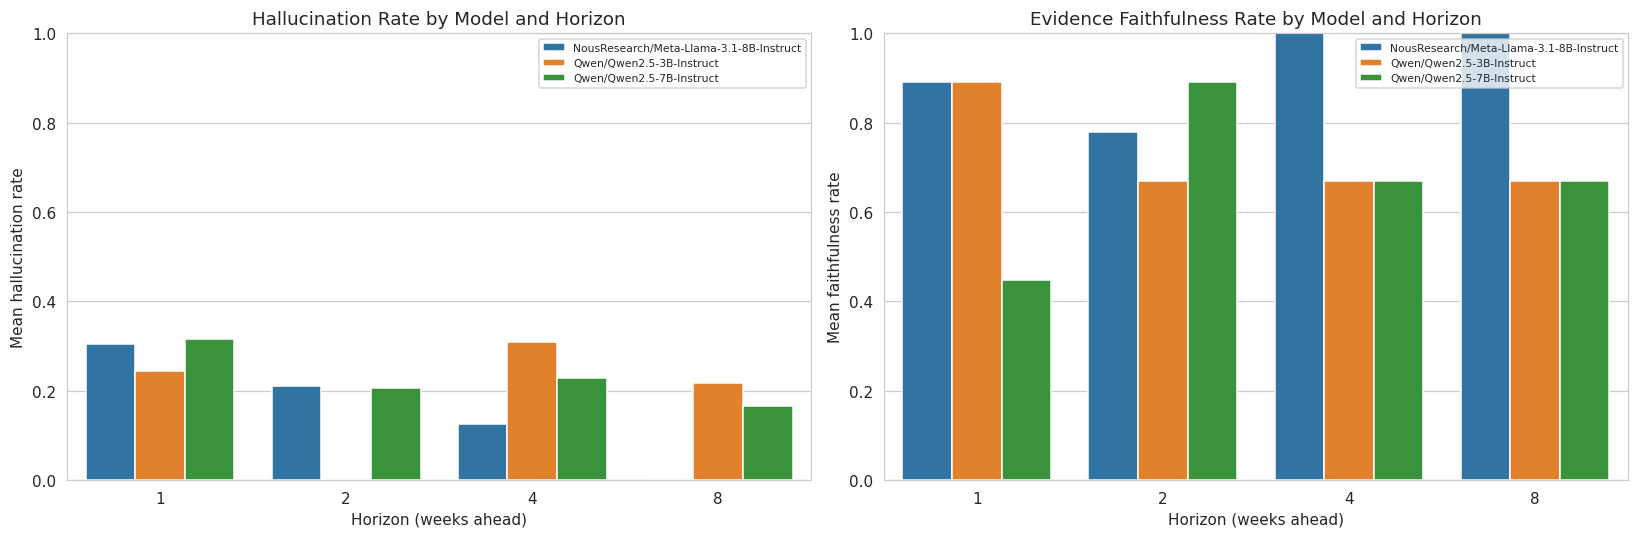

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=table15, x='horizon_weeks', y='mean_hallucination_rate', hue='model', ax=axes[0])
axes[0].set_title('Hallucination Rate by Model and Horizon')
axes[0].set_xlabel('Horizon (weeks ahead)')
axes[0].set_ylabel('Mean hallucination rate')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7, loc='upper right')

sns.barplot(data=table15, x='horizon_weeks', y='mean_faithfulness_rate', hue='model', ax=axes[1])
axes[1].set_title('Evidence Faithfulness Rate by Model and Horizon')
axes[1].set_xlabel('Horizon (weeks ahead)')
axes[1].set_ylabel('Mean faithfulness rate')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig11_llm_evaluation.png'), dpi=150)
plt.show()


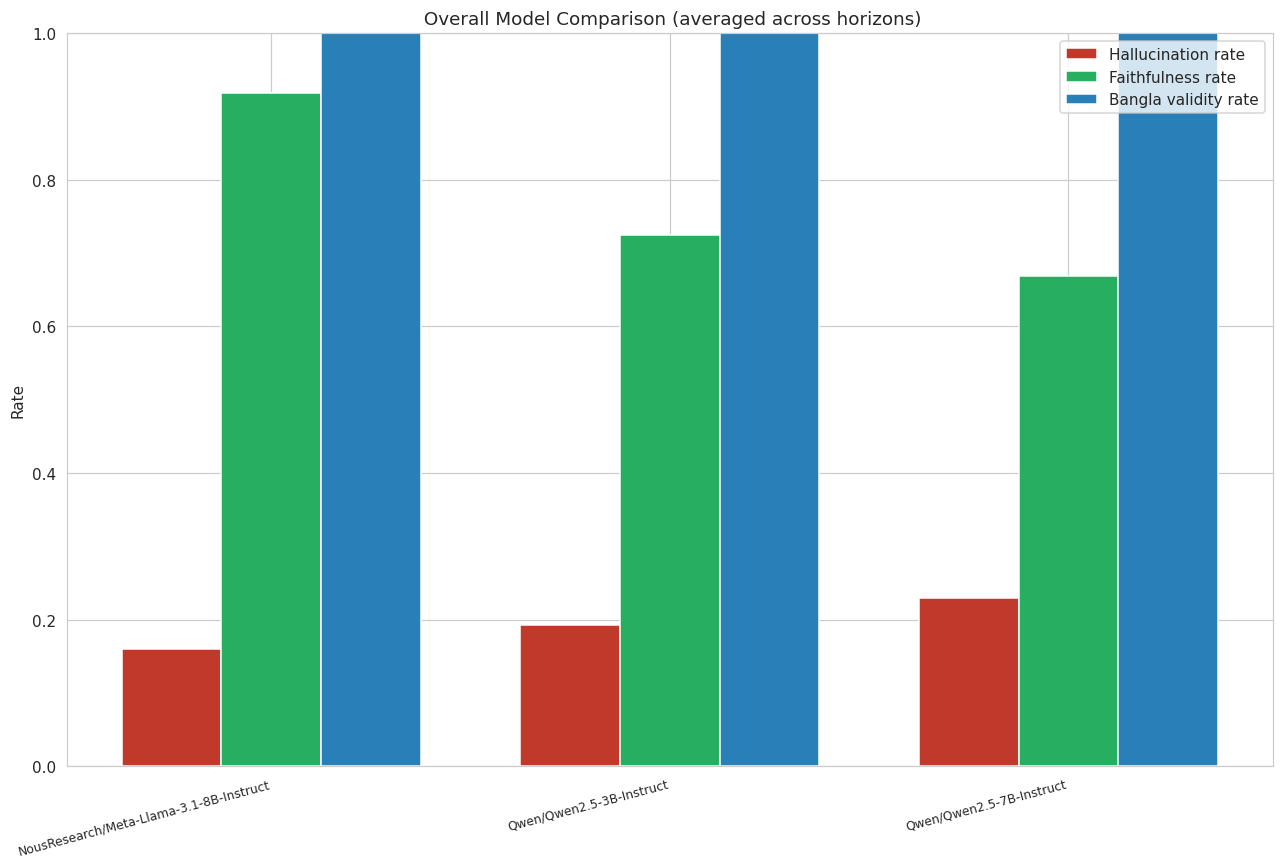

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(table15_model))
width = 0.25
ax.bar(x - width, table15_model['overall_hallucination_rate'], width, label='Hallucination rate', color='#c0392b')
ax.bar(x, table15_model['overall_faithfulness_rate'], width, label='Faithfulness rate', color='#27ae60')
ax.bar(x + width, table15_model['overall_bangla_valid_rate'], width, label='Bangla validity rate', color='#2980b9')
ax.set_xticks(x)
ax.set_xticklabels(table15_model['model'], rotation=15, ha='right', fontsize=8)
ax.set_title(' Overall Model Comparison (averaged across horizons)')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig12_overall_model_comparison.png'), dpi=150)
plt.show()


## 7. Save everything for the paper / write-up

In [17]:
eval_df_save = eval_df.copy()
eval_df_save['hallucinated_values'] = eval_df_save['hallucinated_values'].apply(lambda x: pyjson.dumps(x))
eval_df_save.to_csv(os.path.join(OUTPUT_DIR, 'llm_explanations_evaluated.csv'), index=False)

table15_model.to_json(os.path.join(OUTPUT_DIR, 'llm_evaluation_overall_summary.json'), orient='records', indent=2)

print('Saved:')
print(' -', os.path.join(OUTPUT_DIR, 'llm_explanations_evaluated.csv'))
print(' -', os.path.join(OUTPUT_DIR, 'llm_evaluation_overall_summary.json'))


Saved:
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/llm_explanations_evaluated.csv
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/llm_evaluation_overall_summary.json
